In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 150)

In [7]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("solomonk/reddit_mental_health_posts")

df = pd.DataFrame(dataset['train'])

print(df.shape)
print(df.columns)
print(df['subreddit'].value_counts().head(10))

README.md:   0%|          | 0.00/425 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


adhd.csv:   0%|          | 0.00/29.6M [00:00<?, ?B/s]

aspergers.csv:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

depression.csv:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

ocd.csv:   0%|          | 0.00/29.8M [00:00<?, ?B/s]

ptsd.csv:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/151288 [00:00<?, ? examples/s]

(151288, 10)
Index(['author', 'body', 'created_utc', 'id', 'num_comments', 'score',
       'subreddit', 'title', 'upvote_ratio', 'url'],
      dtype='str')
subreddit
OCD           42826
ADHD          37109
depression    24031
ptsd          24028
aspergers     23294
Name: count, dtype: int64


In [8]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample row:")
print(df.iloc[0])

print("\nSubreddits (your classes):")
print(df['subreddit'].value_counts())

print("\nNull counts:")
print(df.isnull().sum())

Shape: (151288, 10)

Columns: ['author', 'body', 'created_utc', 'id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', 'url']

Sample row:
author                                                                                                                                            HotConversation1273
body            A few months ago I was accepted into this full time software engineering fellowship and it’s made me realize that I CANNOT work sustainably to sav...
created_utc                                                                                                                                  2021-12-22T18:32:56.000Z
id                                                                                                                                                             rmbjwb
num_comments                                                                                                                                                        1
score            

In [9]:
# Combine title + body into one text field
df['text'] = df['title'].fillna('') + ' ' + df['body'].fillna('')
df['text'] = df['text'].str.strip()

# Drop rows where text is basically empty
df = df[df['text'].str.len() > 20].reset_index(drop=True)

# Rename subreddit to label for clarity
df = df.rename(columns={'subreddit': 'label'})

print(f"Usable rows: {len(df)}")
print(df[['text', 'label']].head(3))

Usable rows: 149160
                                                                                                                                                    text  \
0  I get extremely anxious if I’m not working 24/7 A few months ago I was accepted into this full time software engineering fellowship and it’s made ...   
1  I can't will myself to clean my own house, but feel incredibly motivated to clean my girlfriends place? Hey guys, I was curious if anyone else has...   
2  i need some help  \n\ni have 6 exams in the next 2 weeks one of them on monday and i havent studied for any of them and i feel overwhelmed from al...   

  label  
0  ADHD  
1  ADHD  
2  ADHD  


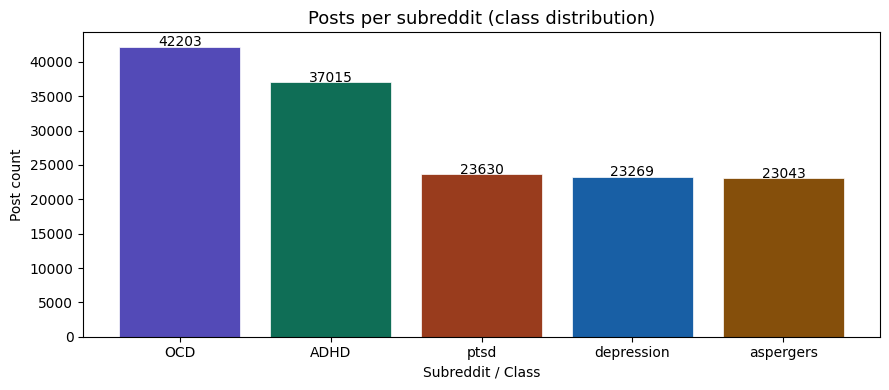

In [11]:
import matplotlib.pyplot as plt
import os

# Ensure folder exists
os.makedirs('../data/processed', exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 4))
counts = df['label'].value_counts()
colors = ['#534AB7', '#0F6E56', '#993C1D', '#185FA5', '#854F0B']

bars = ax.bar(counts.index, counts.values, color=colors[:len(counts)],
              edgecolor='white', linewidth=0.5)

ax.set_title('Posts per subreddit (class distribution)', fontsize=13)
ax.set_xlabel('Subreddit / Class')
ax.set_ylabel('Post count')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/label_distribution.png', dpi=150)
plt.show()

Word count stats by class:
             mean   50%     max
label                          
ADHD        120.9  79.0  6699.0
OCD         105.3  48.0  6288.0
aspergers   108.3  47.0  7237.0
depression  111.3  47.0  4219.0
ptsd        131.8  55.0  5199.0


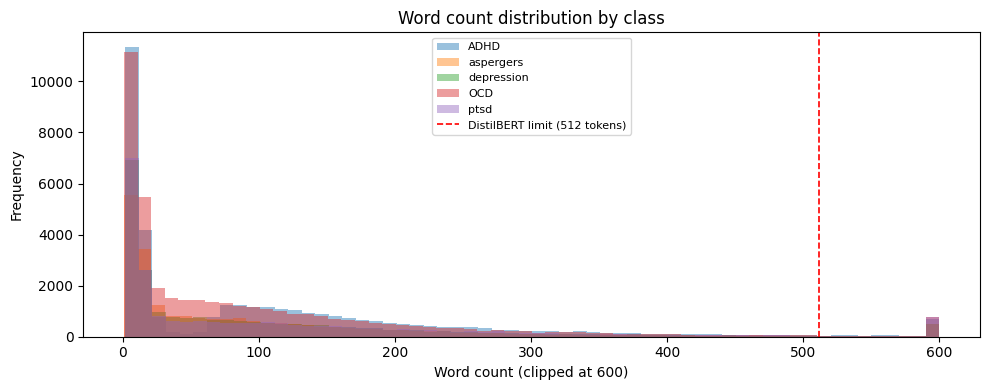


Posts over 512 words: 4530 (3.0%)


In [12]:
df['word_count'] = df['text'].str.split().str.len()

print("Word count stats by class:")
print(df.groupby('label')['word_count'].describe()[['mean','50%','max']].round(1))

fig, ax = plt.subplots(figsize=(10, 4))
for label in df['label'].unique():
    subset = df[df['label'] == label]['word_count']
    ax.hist(subset.clip(upper=600), bins=60, alpha=0.45, label=label)

ax.axvline(512, color='red', linestyle='--', linewidth=1.2, label='DistilBERT limit (512 tokens)')
ax.set_xlabel('Word count (clipped at 600)')
ax.set_ylabel('Frequency')
ax.set_title('Word count distribution by class')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

over_512 = (df['word_count'] > 512).sum()
print(f"\nPosts over 512 words: {over_512} ({over_512/len(df)*100:.1f}%)")

In [13]:
from sklearn.model_selection import train_test_split

# Create label-to-int mapping
labels = sorted(df['label'].unique())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

df['label_id'] = df['label'].map(label2id)

print("Label mapping:")
for k, v in label2id.items():
    print(f"  {v} → {k}")

# Split: 80% train, 10% val, 10% test
train_df, temp_df = train_test_split(df, test_size=0.2, 
                                      stratify=df['label_id'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, 
                                      stratify=temp_df['label_id'], random_state=42)

# Save only what we need
cols = ['text', 'label', 'label_id']
train_df[cols].to_csv('../data/processed/train.csv', index=False)
val_df[cols].to_csv('../data/processed/val.csv',   index=False)
test_df[cols].to_csv('../data/processed/test.csv',  index=False)

print(f"\nSaved → train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

Label mapping:
  0 → ADHD
  1 → OCD
  2 → aspergers
  3 → depression
  4 → ptsd

Saved → train: 119328, val: 14916, test: 14916
